# CC3 — Análise Exploratória de Dados (EDA)

**Projeto:** FlowCarreiras — métricas de perfil de artistas
**Base:** `dados/perfil_features.csv` (400 perfis simulados, 1 linha por perfil — ver [CC2](CC2_plano_de_preparacao_dos_dados.md))

Este notebook realiza a análise exploratória prevista no [CC1](CC1_plano_de_analise.md):
distribuições, correlações, relações por categoria e **agrupamento (clustering)**,
cada bloco acompanhado de **interpretação textual**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

%matplotlib inline
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 90
ROXO = '#7c3aed'
pd.set_option('display.max_columns', 60)

df = pd.read_csv('dados/perfil_features.csv')
print('Dimensões:', df.shape)
df.head()

Dimensões: (400, 33)


,perfil_id,usuario_id,percentual_completude,onboarding_concluido,cidade,area_artistica,disponivel_para_mentorar,perfil_mentor_configurado,recebe_notificacoes,entrou_fila,n_obras,n_obras_publicadas,diversidade_midia,curtidas_recebidas,comentarios_recebidos,n_links,n_tags_necessidade,n_tags_expertise,n_mentorias_mentor,n_mentorias_artista,n_notificacoes,seguidores,seguindo,curtidas_dadas,comentarios_feitos,tem_bio,tem_foto,tem_cidade,tem_area,idade_conta_dias,n_rascunhos,media_curtidas_por_obra,razao_seg
0,3acc55e8-c333-453d-aa1b-5a9e608ccced,a7e14df5-e9e1-4ec4-a541-d845c83d270b,80,1,Salvador,Circo,0,0,1,0,0,0,0,0,0,2,2,1,0,1,4,3,0,17,0,0,0,1,1,87,0,0.000000,0.0
1,ad9bbbd5-e03f-46d1-b693-560c9bf01e58,d9c538bb-06e9-447f-9c33-42cb3e706733,70,0,Não informado,Dança,0,0,1,0,1,0,1,0,0,3,2,2,0,1,2,5,2,14,1,0,1,0,1,709,1,0.000000,2.5
2,6f8e9175-a31d-42d2-8af1-3fa1087ded2f,c9b64399-32df-46b3-b72b-e348a72b50a9,85,1,Cabo de Santo Agostinho,Performance,1,0,1,0,0,0,0,0,0,0,1,1,0,0,2,1,0,16,1,0,1,1,1,165,0,0.000000,0.0
3,9d75857c-22b6-4aba-a83a-b6d568a9c1f5,78e94db3-8f6d-4d1e-9632-1ed695cd08cf,75,1,Jaboatão dos Guararapes,Teatro,1,1,1,1,2,2,2,4,4,0,3,0,4,2,3,5,10,20,1,0,0,1,1,539,0,2.000000,0.5
4,8097385b-38dc-4063-99f7-ec576ebdd3e9,bbe3b174-e1ea-4f24-8a70-74fbfc72fb4a,65,1,Olinda,Artesanato,0,0,1,1,3,3,2,2,0,1,0,2,0,0,2,5,0,26,1,1,0,1,1,136,0,0.666667,0.0


## 1. Estatística descritiva

Primeiro olhar sobre a tendência central e a dispersão das variáveis numéricas.

In [2]:
df.describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']].round(2)

,mean,std,min,25%,50%,75%,max
percentual_completude,80.16,15.77,20.0,70.00,85.00,90.00,100.0
onboarding_concluido,0.82,0.39,0.0,1.00,1.00,1.00,1.0
disponivel_para_mentorar,0.27,0.44,0.0,0.00,0.00,1.00,1.0
perfil_mentor_configurado,0.18,0.38,0.0,0.00,0.00,0.00,1.0
recebe_notificacoes,0.82,0.38,0.0,1.00,1.00,1.00,1.0
entrou_fila,0.59,0.49,0.0,0.00,1.00,1.00,1.0
n_obras,3.40,3.03,0.0,1.00,3.00,5.00,13.0
n_obras_publicadas,2.69,2.50,0.0,0.00,2.00,4.00,11.0
diversidade_midia,1.80,1.31,0.0,1.00,2.00,3.00,4.0
curtidas_recebidas,17.05,22.96,0.0,0.00,6.00,28.00,110.0


**Leitura inicial.** Observa-se de imediato a marca registrada de dados de engajamento:
a **média é muito maior que a mediana** em `curtidas_recebidas`, `seguidores` e `n_obras`,
e o **desvio-padrão é da ordem da própria média** — sinais clássicos de distribuições
**assimétricas à direita (cauda longa)**. Já `percentual_completude` se concentra em
valores altos (mediana ~85), distribuição assimétrica à esquerda. Isso justifica, mais
adiante, o uso de **escala logarítmica** e de **mediana/IQR** em vez de média/desvio.

## 2. Distribuições

Histograma (forma) + boxplot (mediana, IQR, outliers) para as variáveis-chave.

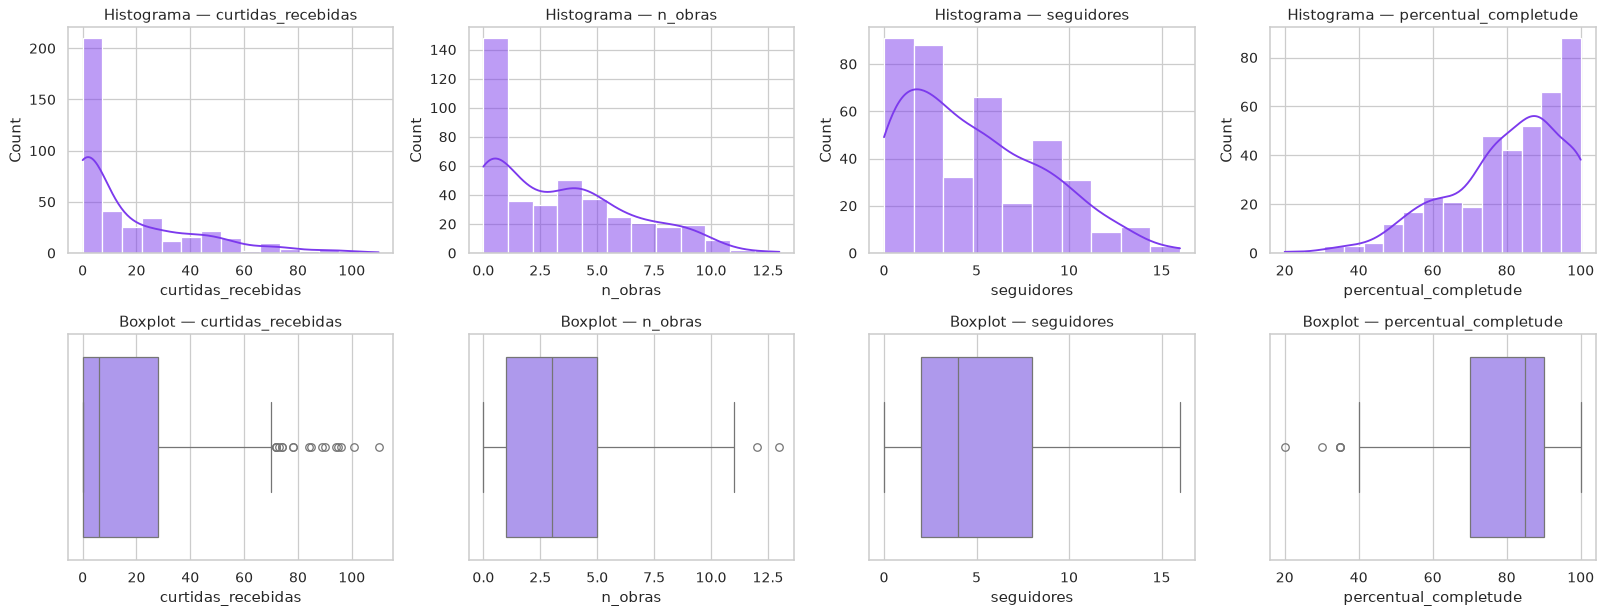

In [3]:
vars_dist = ['curtidas_recebidas', 'n_obras', 'seguidores', 'percentual_completude']
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for i, v in enumerate(vars_dist):
    sns.histplot(df[v], kde=True, ax=axes[0, i], color=ROXO)
    axes[0, i].set_title(f'Histograma — {v}')
    sns.boxplot(x=df[v], ax=axes[1, i], color='#a78bfa')
    axes[1, i].set_title(f'Boxplot — {v}')
plt.tight_layout()
plt.show()

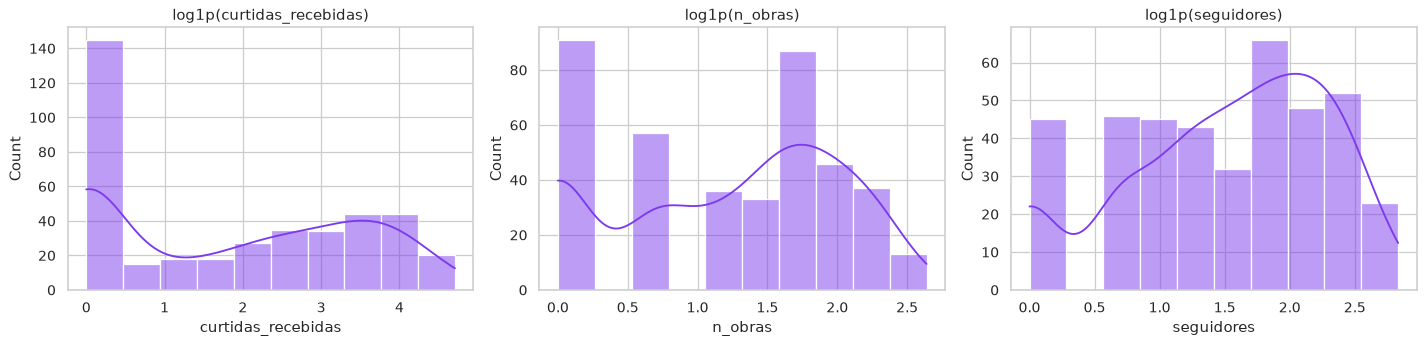

In [4]:
# Efeito da transformação log1p nas contagens assimétricas
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, v in enumerate(['curtidas_recebidas', 'n_obras', 'seguidores']):
    sns.histplot(np.log1p(df[v]), kde=True, ax=axes[i], color=ROXO)
    axes[i].set_title(f'log1p({v})')
plt.tight_layout()
plt.show()

**Interpretação.** As contagens de engajamento têm **forte concentração em valores baixos**
e uma cauda de poucos perfis muito populares (boxplots com vários outliers superiores) —
o engajamento é **desigual**: a maioria recebe pouco e um grupo pequeno concentra muito.
A transformação **`log1p`** aproxima as contagens de uma forma mais simétrica, o que é
desejável para os gráficos de dispersão (CC4) e para algoritmos sensíveis à escala (clustering).
A `percentual_completude`, ao contrário, está deslocada para a direita: a maioria dos perfis
já é bastante completa.

## 3. Correlações

Matriz de Pearson entre os principais atributos e os alvos de modelagem.

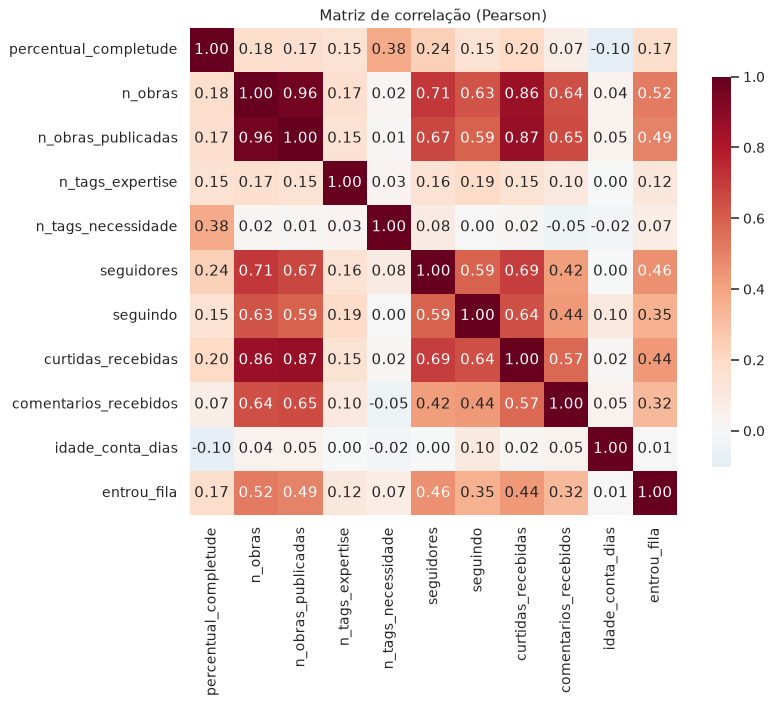

In [5]:
feat_corr = ['percentual_completude', 'n_obras', 'n_obras_publicadas', 'n_tags_expertise',
             'n_tags_necessidade', 'seguidores', 'seguindo', 'curtidas_recebidas',
             'comentarios_recebidos', 'idade_conta_dias', 'entrou_fila']
corr = df[feat_corr].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True,
            cbar_kws={'shrink': 0.8})
plt.title('Matriz de correlação (Pearson)')
plt.tight_layout()
plt.show()

**Interpretação.** O engajamento recebido (`curtidas_recebidas`) é fortemente explicado pelo
**volume de produção**: correlação alta com `n_obras_publicadas` e `n_obras` (~0,9) e
moderada-alta com `seguidores` (~0,7). A `percentual_completude` tem correlação **fraca-positiva**
(~0,2) — completar o perfil ajuda, mas é o **produzir e acumular rede** que move o engajamento.
`idade_conta_dias` quase não correlaciona, indicando que **antiguidade por si só não gera
engajamento**. O alvo `entrou_fila` acompanha as mesmas variáveis de produção/engajamento,
o que antecipa que um classificador simples (CC5) deve funcionar bem.

## 4. Relações por categoria (análise multivariada)

Engajamento segmentado por **área artística** — combinando uma variável categórica com uma
quantitativa.

/tmp/ipykernel_17/438172745.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x='area_artistica', y='curtidas_recebidas', palette='Purples')


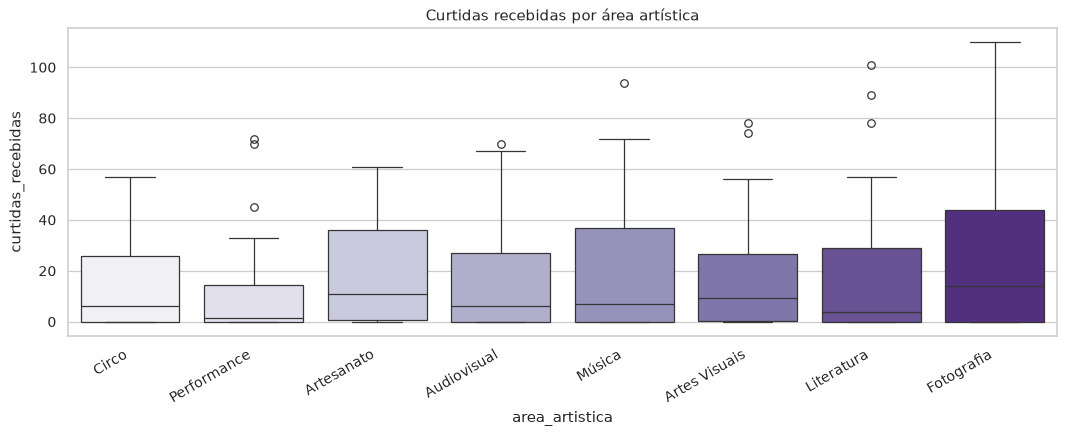

,curtidas_recebidas,seguidores,percentual_completude
area_artistica,,,
Fotografia,26.7,5.5,83.5
Música,19.3,5.3,82.9
Artesanato,19.3,5.5,82.1
Não informado,18.9,5.5,52.8
Artes Visuais,17.9,5.7,81.8
Literatura,17.6,4.3,82.6
Audiovisual,15.4,4.3,80.3
Dança,15.1,4.2,83.3
Circo,13.7,4.6,83.3


In [6]:
top_areas = df['area_artistica'].value_counts().index[:8]
sub = df[df['area_artistica'].isin(top_areas)]
plt.figure(figsize=(12, 5))
sns.boxplot(data=sub, x='area_artistica', y='curtidas_recebidas', palette='Purples')
plt.xticks(rotation=30, ha='right')
plt.title('Curtidas recebidas por área artística')
plt.tight_layout()
plt.show()

(df.groupby('area_artistica')[['curtidas_recebidas', 'seguidores', 'percentual_completude']]
   .mean().sort_values('curtidas_recebidas', ascending=False).round(1))

**Interpretação.** Como os dados foram simulados sem privilegiar nenhuma área, as medianas de
engajamento entre áreas são **semelhantes** — a variação dentro de cada área (perfis ativos vs.
inativos) é **maior que a variação entre áreas**. Isso é um insight legítimo: o desempenho
depende muito mais do **comportamento do artista** (produzir, completar, engajar) do que da
**categoria** a que pertence. Diferenças observadas tendem a refletir o tamanho da amostra de
cada área, não um efeito real de área.

## 5. Agrupamento (clustering)

Segmentação não supervisionada dos perfis. Contagens recebem `log1p`, tudo é padronizado
(z-score, pois k-means é sensível à escala), e o número de clusters é escolhido pela
**silhueta**.

In [7]:
feats = ['percentual_completude', 'n_obras', 'n_obras_publicadas', 'curtidas_recebidas',
         'comentarios_recebidos', 'seguidores', 'seguindo', 'n_tags_expertise']
X = df[feats].copy()
for c in ['n_obras', 'n_obras_publicadas', 'curtidas_recebidas',
          'comentarios_recebidos', 'seguidores', 'seguindo']:
    X[c] = np.log1p(X[c])
Xs = StandardScaler().fit_transform(X)

sils = {}
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(Xs)
    sils[k] = silhouette_score(Xs, km.labels_)
print('Silhueta por k:', {k: round(v, 3) for k, v in sils.items()})
melhor_k = max(sils, key=sils.get)
print('k escolhido:', melhor_k)

km = KMeans(n_clusters=melhor_k, random_state=42, n_init=10).fit(Xs)
df['cluster'] = km.labels_

Silhueta por k: {2: 0.367, 3: 0.239, 4: 0.214, 5: 0.2, 6: 0.181}
k escolhido: 2


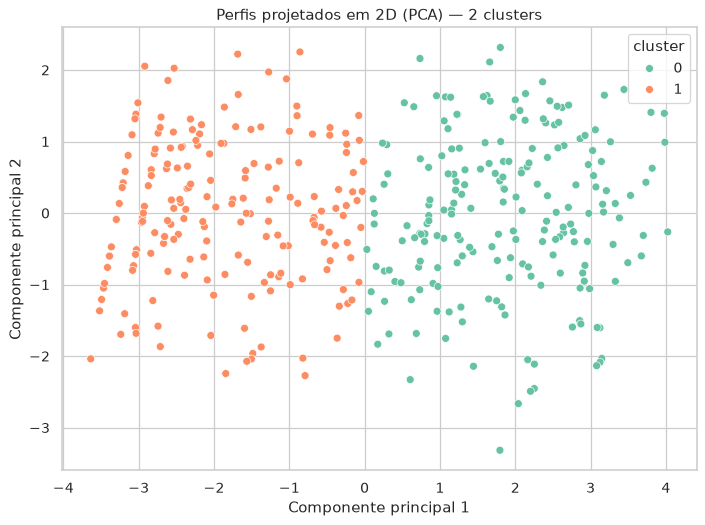

In [8]:
# Projeção 2D (PCA) para visualizar os agrupamentos
proj = PCA(n_components=2).fit_transform(Xs)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=proj[:, 0], y=proj[:, 1], hue=df['cluster'], palette='Set2', s=40)
plt.title(f'Perfis projetados em 2D (PCA) — {melhor_k} clusters')
plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.legend(title='cluster')
plt.tight_layout()
plt.show()

In [9]:
# Perfil médio de cada cluster (para nomear os segmentos)
df.groupby('cluster')[feats + ['entrou_fila']].mean().round(1)

,percentual_completude,n_obras,n_obras_publicadas,curtidas_recebidas,comentarios_recebidos,seguidores,seguindo,n_tags_expertise,entrou_fila
cluster,,,,,,,,,
0,83.3,5.7,4.6,32.6,3.6,7.5,8.3,1.9,0.9
1,76.9,1.0,0.8,1.0,0.4,2.1,1.2,1.3,0.3


**Interpretação.** A silhueta indica a melhor separação no `k` impresso acima. Lendo a tabela
de médias por cluster, os grupos se ordenam claramente ao longo de um eixo de **atividade /
maturidade**: de um lado, perfis com **baixa completude, poucas obras e pouco engajamento**
(artistas iniciantes ou inativos); do outro, perfis **completos, produtivos e com alto
engajamento e rede** (artistas consolidados), tipicamente com maior taxa de `entrou_fila`.
A projeção PCA confirma visualmente essa gradação. Esses segmentos são **acionáveis**: a
plataforma pode, por exemplo, incentivar completude e publicação nos clusters menos ativos.

## 6. Síntese de insights

- **O engajamento é desigual (cauda longa):** poucos artistas concentram a maior parte das
  curtidas e seguidores; a mediana descreve o artista típico melhor que a média.
- **Produção é o principal motor do engajamento:** `n_obras_publicadas` é a variável mais
  associada às curtidas recebidas (~0,9), seguida da rede de seguidores (~0,7).
- **Completar o perfil ajuda, mas pouco isoladamente** (correlação ~0,2): o diferencial está
  em **produzir e acumular rede**, não apenas em preencher campos.
- **Antiguidade não gera engajamento:** `idade_conta_dias` é praticamente não correlacionada.
- **Área artística não determina desempenho:** a variação intra-área supera a variação
  entre áreas.
- **Existem segmentos naturais de artistas** (iniciantes/inativos → consolidados), úteis para
  ações de produto e coerentes com o alvo de descoberta.
- **O alvo `entrou_fila` é previsível** pelas variáveis de produção/engajamento — base sólida
  para o classificador do CC5.